## Project 1: 3D object detection

### Creation of the enviroment for the MMDet3D library

In [2]:
import os
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Configurazione PATH Miniconda
if not os.path.exists("/usr/local/miniconda"):
    print(" Configuration of the Conda environment for the first time...")
    !wget -q https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O /tmp/miniconda.sh
    !bash /tmp/miniconda.sh -b -p /usr/local/miniconda
    os.environ["PATH"] = "/usr/local/miniconda/bin:" + os.environ["PATH"]

    !conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
    !conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r
    
    !conda create -n openmmlab python=3.10 -y
    !conda run -n openmmlab pip install "numpy<2" torch==2.0.1 torchvision==0.15.2 --index-url https://download.pytorch.org/whl/cu118
    !conda run -n openmmlab pip install -U openmim
    !conda run -n openmmlab mim install mmengine "mmcv>=2.0.0rc4,<2.1.0" "mmdet>=3.0.0,<3.1.0"
    
    if not os.path.exists('/content/mmdetection3d'):
        !git clone https://github.com/open-mmlab/mmdetection3d.git -b dev-1.x /content/mmdetection3d
        %cd /content/mmdetection3d
        !conda run -n openmmlab pip install --no-build-isolation .
        %cd /content
    !conda run -n openmmlab pip install "numpy<2"
else:
    os.environ["PATH"] = "/usr/local/miniconda/bin:" + os.environ["PATH"]
    print(" Conda environment is already ready!")
    
    print(" Conda environment and OpenMMLab are active!")

Mounted at /content/drive
 Configuration of the Conda environment for the first time...
PREFIX=/usr/local/miniconda
Unpacking bootstrapper...
Unpacking payload...

Installing base environment...

Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please verify that your PYTHONPATH only points to
    directories of packages that are compatible with the Python interpreter
    in Miniconda3: /usr/local/miniconda
accepted Terms of Service for https://repo.anaconda.com/pkgs/main
accepted Terms of Service for https://repo.anaconda.com/pkgs/r
Jupyter detected...
2 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.7.1


### Cloning the repo from GitHub

In [1]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

%cd /content
if not os.path.exists('/content/3D_Perception'):
    !git clone https://github.com/giacomosalvatori03/3D_Perception.git
%cd /content/3D_Perception
!git pull

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content
/content/3D_Perception
Already up to date.


## 1° experiment: random dropout for the LiDAR points

### Baseline evaluation

In [46]:
%%bash
source /usr/local/miniconda/bin/activate openmmlab

cd /content/3D_Perception
git pull

python -u validate_lidar.py --subsample_mode none --max_samples 500

Updating 9f8747c..c43c05d
Fast-forward
 notebooks/01_lidar_degradation.ipynb | 98 +++++++++++++++++++++++-------------
 src/kitti_dataset.py                 |  2 +-
 2 files changed, 65 insertions(+), 35 deletions(-)
 Loading PointPillars on cuda:0
Loads checkpoint by local backend from path: /content/3D_Perception/weights/pointpillar_kitti.pth
 Classes mapping extracted from the model: ['Pedestrian', 'Cyclist', 'Car']

 Starting PointPillars Inference [BASELINE_100PERC] | Samples: 500/3769
 Destination for .txt files on Drive: /content/drive/MyDrive/3D_Perception/experiments/baseline_100perc

 Inference and saving completed successfully!
  • Predictions saved in: /content/drive/MyDrive/3D_Perception/experiments/baseline_100perc/pred_labels
  • Ground Truth saved in: /content/drive/MyDrive/3D_Perception/experiments/baseline_100perc/gt_labels


From https://github.com/giacomosalvatori03/3D_Perception
   9f8747c..c43c05d  main       -> origin/main
/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/mmdet3d/models/dense_heads/anchor3d_head.py:94: UserWarning: dir_offset and dir_limit_offset will be depressed and be incorporated into box coder in the future
  warnings.warn(
Processing Frames:   0%|          | 0/500 [00:00<?, ?it/s]/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Processing Frames: 100%|██████████| 500/500 [00:29<00:00, 16.69it/s]


In [3]:
import sys

sys.path.insert(0, "/content/3D_Perception")
from scripts.lidar_evaluator import KittiEvaluator

evaluator = KittiEvaluator()
exp_path = (
    "/content/drive/MyDrive/3D_Perception/experiments/baseline_100perc"
)

# 1. Standard Evaluation (Overall mAP40)
df_global = evaluator.evaluate(exp_path)

# 2. Range Based Evaluation (Near, Medium, Far)
df_range = evaluator.evaluate_ranges(exp_path)


 OVERALL 3D DETECTION mAP40 [baseline_100perc]



,Easy,Moderate,Hard
Class,,,
Car,67.40%,62.71%,59.77%
Pedestrian,53.82%,49.63%,44.13%
Cyclist,48.11%,43.70%,42.59%



 Reports saved in '/content/drive/MyDrive/3D_Perception/experiments/baseline_100perc': .json, .csv, .md, .tex

 RANGE-BASED mAP40 RESULTS [baseline_100perc]



Class,Car,Cyclist,Pedestrian
Range,,,
Far (40-70m),19.23%,60.77%,0.00%
Medium (20-40m),54.74%,34.21%,23.54%
Near (0-20m),80.82%,53.02%,59.85%



 Range reports saved in '/content/drive/MyDrive/3D_Perception/experiments/baseline_100perc': .csv, .json


### Random drop (75% keep) evaluation 

In [48]:
%%bash
source /usr/local/miniconda/bin/activate openmmlab

cd /content/3D_Perception
git pull

python -u validate_lidar.py --subsample_mode random --subsample_ratio 0.75 --max_samples 500

Already up to date.
 Loading PointPillars on cuda:0
Loads checkpoint by local backend from path: /content/3D_Perception/weights/pointpillar_kitti.pth
 Classes mapping extracted from the model: ['Pedestrian', 'Cyclist', 'Car']

 Starting PointPillars Inference [RANDOM_75PERC] | Samples: 500/3769
 Destination for .txt files on Drive: /content/drive/MyDrive/3D_Perception/experiments/random_75perc

 Inference and saving completed successfully!
  • Predictions saved in: /content/drive/MyDrive/3D_Perception/experiments/random_75perc/pred_labels
  • Ground Truth saved in: /content/drive/MyDrive/3D_Perception/experiments/random_75perc/gt_labels


/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/mmdet3d/models/dense_heads/anchor3d_head.py:94: UserWarning: dir_offset and dir_limit_offset will be depressed and be incorporated into box coder in the future
  warnings.warn(
Processing Frames:   0%|          | 0/500 [00:00<?, ?it/s]/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Processing Frames: 100%|██████████| 500/500 [00:29<00:00, 16.90it/s]


In [82]:
import sys

sys.path.insert(0, "/content/3D_Perception")
from scripts.lidar_evaluator import KittiEvaluator

evaluator = KittiEvaluator()
exp_path = (
    "/content/drive/MyDrive/3D_Perception/experiments/random_75perc"
)

# 1. Standard Evaluation (Overall mAP40)
df_global = evaluator.evaluate(exp_path)

# 2. Range Based Evaluation (Near, Medium, Far)
df_range = evaluator.evaluate_ranges(exp_path)


 OVERALL 3D DETECTION mAP40 [random_75perc]



,Easy,Moderate,Hard
Class,,,
Car,65.34%,59.62%,56.88%
Pedestrian,55.25%,49.38%,44.93%
Cyclist,50.24%,40.88%,40.34%



 Reports saved in '/content/drive/MyDrive/3D_Perception/experiments/random_75perc': .json, .csv, .md, .tex

 RANGE-BASED mAP40 RESULTS [random_75perc]



Class,Car,Cyclist,Pedestrian
Range,,,
Far (40-70m),14.04%,30.71%,0.00%
Medium (20-40m),48.99%,32.06%,27.15%
Near (0-20m),79.02%,56.37%,57.19%



 Range reports saved in '/content/drive/MyDrive/3D_Perception/experiments/random_75perc': .csv, .json


### Random drop (50% keep) evaluation

In [52]:
%%bash
source /usr/local/miniconda/bin/activate openmmlab

cd /content/3D_Perception
git pull

python -u validate_lidar.py --subsample_mode random --subsample_ratio 0.50 --max_samples 500

Already up to date.
 Loading PointPillars on cuda:0
Loads checkpoint by local backend from path: /content/3D_Perception/weights/pointpillar_kitti.pth
 Classes mapping extracted from the model: ['Pedestrian', 'Cyclist', 'Car']

 Starting PointPillars Inference [RANDOM_50PERC] | Samples: 500/3769
 Destination for .txt files on Drive: /content/drive/MyDrive/3D_Perception/experiments/random_50perc

 Inference and saving completed successfully!
  • Predictions saved in: /content/drive/MyDrive/3D_Perception/experiments/random_50perc/pred_labels
  • Ground Truth saved in: /content/drive/MyDrive/3D_Perception/experiments/random_50perc/gt_labels


/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/mmdet3d/models/dense_heads/anchor3d_head.py:94: UserWarning: dir_offset and dir_limit_offset will be depressed and be incorporated into box coder in the future
  warnings.warn(
Processing Frames:   0%|          | 0/500 [00:00<?, ?it/s]/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Processing Frames: 100%|██████████| 500/500 [00:29<00:00, 16.97it/s]


In [83]:
import sys

sys.path.insert(0, "/content/3D_Perception")
from scripts.lidar_evaluator import KittiEvaluator

evaluator = KittiEvaluator()
exp_path = (
    "/content/drive/MyDrive/3D_Perception/experiments/random_50perc"
)

# 1. Standard Evaluation (Overall mAP40)
df_global = evaluator.evaluate(exp_path)

# 2. Range Based Evaluation (Near, Medium, Far)
df_range = evaluator.evaluate_ranges(exp_path)


 OVERALL 3D DETECTION mAP40 [random_50perc]



,Easy,Moderate,Hard
Class,,,
Car,65.17%,54.77%,51.99%
Pedestrian,54.77%,49.56%,44.68%
Cyclist,46.91%,35.78%,35.57%



 Reports saved in '/content/drive/MyDrive/3D_Perception/experiments/random_50perc': .json, .csv, .md, .tex

 RANGE-BASED mAP40 RESULTS [random_50perc]



Class,Car,Cyclist,Pedestrian
Range,,,
Far (40-70m),11.63%,7.17%,0.00%
Medium (20-40m),46.10%,21.97%,18.54%
Near (0-20m),75.03%,59.17%,58.62%



 Range reports saved in '/content/drive/MyDrive/3D_Perception/experiments/random_50perc': .csv, .json


### Random drop (25% keep) evaluation

In [54]:
%%bash
source /usr/local/miniconda/bin/activate openmmlab

cd /content/3D_Perception
git pull

python -u validate_lidar.py --subsample_mode random --subsample_ratio 0.25 --max_samples 500

Already up to date.
 Loading PointPillars on cuda:0
Loads checkpoint by local backend from path: /content/3D_Perception/weights/pointpillar_kitti.pth
 Classes mapping extracted from the model: ['Pedestrian', 'Cyclist', 'Car']

 Starting PointPillars Inference [RANDOM_25PERC] | Samples: 500/3769
 Destination for .txt files on Drive: /content/drive/MyDrive/3D_Perception/experiments/random_25perc

 Inference and saving completed successfully!
  • Predictions saved in: /content/drive/MyDrive/3D_Perception/experiments/random_25perc/pred_labels
  • Ground Truth saved in: /content/drive/MyDrive/3D_Perception/experiments/random_25perc/gt_labels


/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/mmdet3d/models/dense_heads/anchor3d_head.py:94: UserWarning: dir_offset and dir_limit_offset will be depressed and be incorporated into box coder in the future
  warnings.warn(
Processing Frames:   0%|          | 0/500 [00:00<?, ?it/s]/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Processing Frames: 100%|██████████| 500/500 [00:27<00:00, 18.06it/s]


In [84]:
import sys

sys.path.insert(0, "/content/3D_Perception")
from scripts.lidar_evaluator import KittiEvaluator

evaluator = KittiEvaluator()
exp_path = (
    "/content/drive/MyDrive/3D_Perception/experiments/random_25perc"
)

# 1. Standard Evaluation (Overall mAP40)
df_global = evaluator.evaluate(exp_path)

# 2. Range Based Evaluation (Near, Medium, Far)
df_range = evaluator.evaluate_ranges(exp_path)


 OVERALL 3D DETECTION mAP40 [random_25perc]



,Easy,Moderate,Hard
Class,,,
Car,55.26%,43.81%,39.42%
Pedestrian,45.55%,40.10%,35.57%
Cyclist,28.50%,20.25%,21.25%



 Reports saved in '/content/drive/MyDrive/3D_Perception/experiments/random_25perc': .json, .csv, .md, .tex

 RANGE-BASED mAP40 RESULTS [random_25perc]



Class,Car,Cyclist,Pedestrian
Range,,,
Far (40-70m),4.84%,0.00%,0.00%
Medium (20-40m),28.62%,11.42%,6.57%
Near (0-20m),69.42%,37.58%,50.13%



 Range reports saved in '/content/drive/MyDrive/3D_Perception/experiments/random_25perc': .csv, .json


### Visualize the baseline

 Saved compact grid visualization to Drive: /content/drive/MyDrive/3D_Perception/experiments/baseline_100perc/visualizations/summary_grid_bev.png


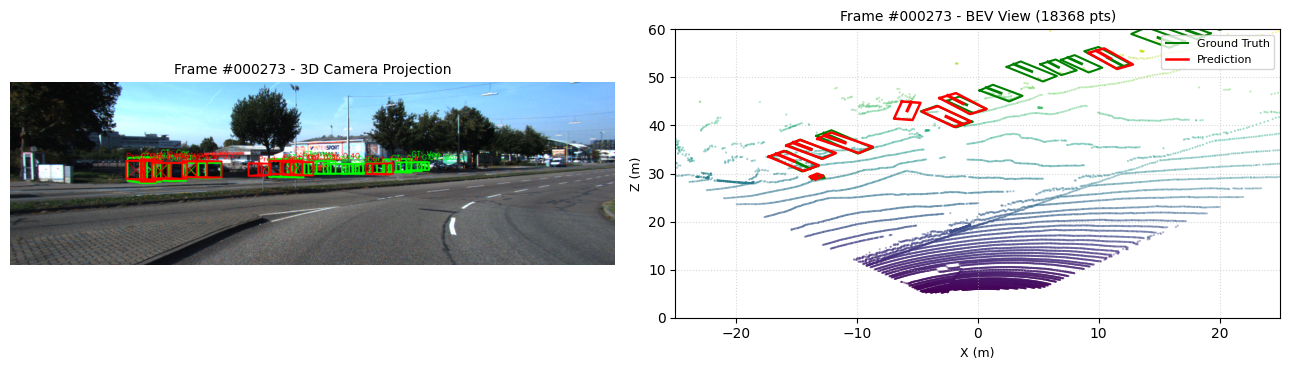

In [ ]:
import sys

sys.path.insert(0, "/content/3D_Perception")

from scripts.sample_visualizer import SampleVisualizer

# Initialize and render
visualizer = SampleVisualizer(
    data_path="/content/drive/MyDrive/3D_Perception/data/kitti_validation"
)

visualizer.visualize_experiment(
    exp_dir="/content/drive/MyDrive/3D_Perception/experiments/baseline_100perc",
    num_samples=1,
    conf_thresh=0.3,
    grid_layout=True,
)

### Visualize the 50% keep

 Saved compact grid visualization to Drive: /content/drive/MyDrive/3D_Perception/experiments/random_50perc/visualizations/summary_grid_bev.png


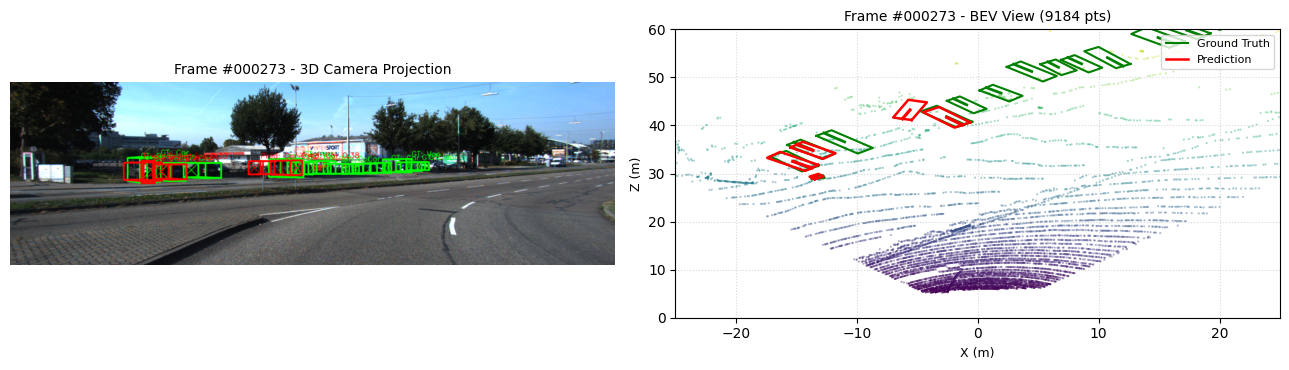

In [2]:
import sys

sys.path.insert(0, "/content/3D_Perception")
from scripts.sample_visualizer import SampleVisualizer

# Inizializzazione
visualizer = SampleVisualizer(
    data_path="/content/drive/MyDrive/3D_Perception/data/kitti_validation"
)

# Visualizza i 3 frame più significativi
visualizer.visualize_experiment(
    exp_dir="/content/drive/MyDrive/3D_Perception/experiments/random_50perc",
    num_samples=1,
    conf_thresh=0.3,
)

### Visualize the 25% keep

 Saved compact grid visualization to Drive: /content/drive/MyDrive/3D_Perception/experiments/random_25perc/visualizations/summary_grid_bev.png


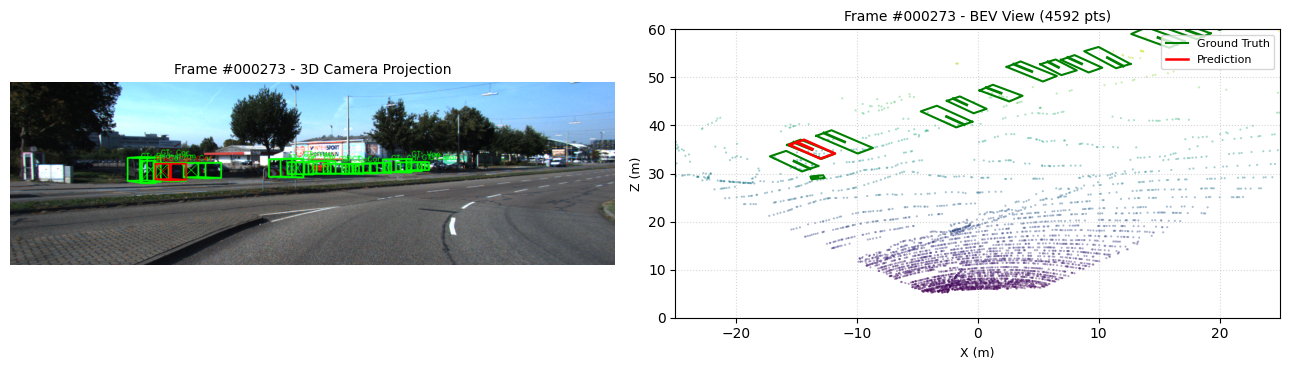

In [1]:
import sys

sys.path.insert(0, "/content/3D_Perception")
from scripts.sample_visualizer import SampleVisualizer

# Inizializzazione
visualizer = SampleVisualizer(
    data_path="/content/drive/MyDrive/3D_Perception/data/kitti_validation"
)

# Visualizza i 3 frame più significativi
visualizer.visualize_experiment(
    exp_dir="/content/drive/MyDrive/3D_Perception/experiments/random_25perc",
    num_samples=1,
    conf_thresh=0.3,
)

### Experiment comparison

 Overall degradation plot saved to: /content/drive/MyDrive/3D_Perception/experiments/random_degradation_car.png


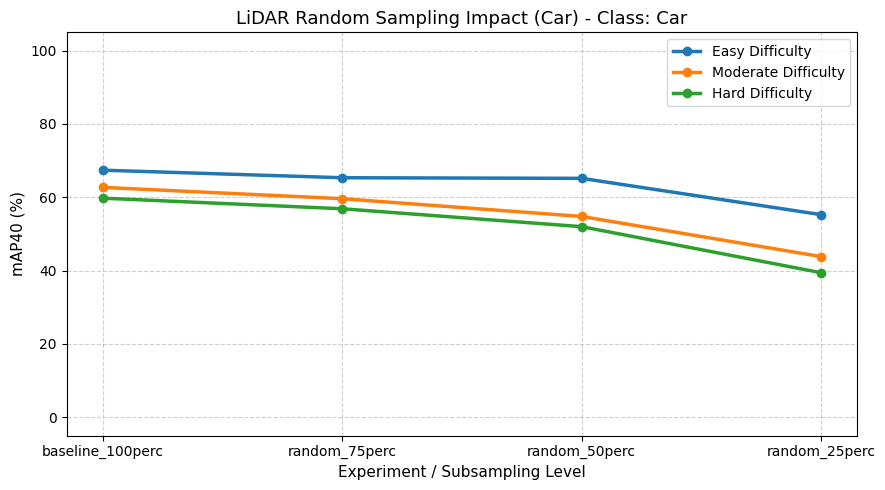

 Range degradation plot saved to: /content/drive/MyDrive/3D_Perception/experiments/range_degradation.png


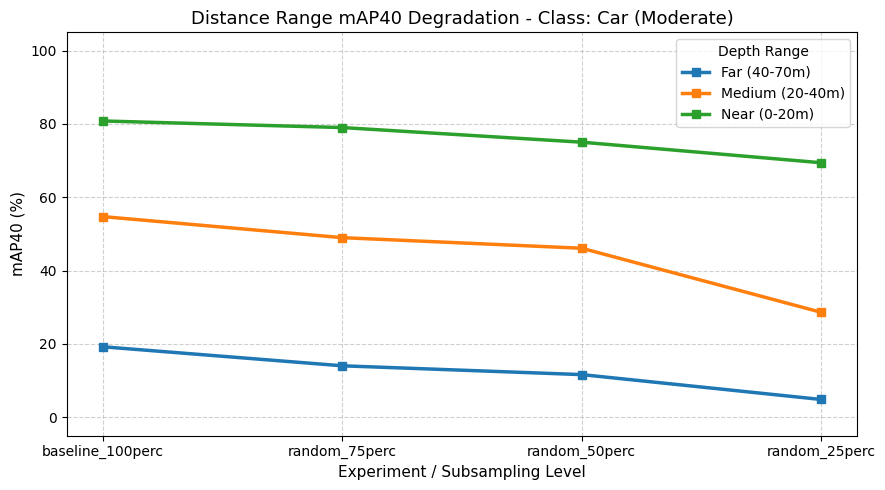

In [ ]:
import sys

sys.path.insert(0, "/content/3D_Perception")

from scripts.experiment_comparer import ExperimentComparer

comparer = ExperimentComparer()

# Degradation curve for random sampling experiments
exp_sequence = ["baseline_100perc", "random_75perc", "random_50perc", "random_25perc"]

comparer.plot_degradation_curves(
    exp_order=exp_sequence,
    target_class="Car",
    title="LiDAR Random Sampling Impact (Car)",
    save_path="/content/drive/MyDrive/3D_Perception/experiments/random_degradation_car.png",
)

# Degradation curve for range-based evaluation (Near, Medium, Far)
comparer.plot_range_degradation_curves(
    exp_order=exp_sequence,
    target_class="Car",
    difficulty="Moderate",
    save_path="/content/drive/MyDrive/3D_Perception/experiments/range_degradation.png",
)

## 2° experiment: dropout in the beams of the LiDAR

### Baseline evaluation: 64 beams

In [59]:
%%bash
source /usr/local/miniconda/bin/activate openmmlab

cd /content/3D_Perception
git pull

python -u validate_lidar.py --subsample_mode beam --num_beams 64 --max_samples 500

Already up to date.
 Loading PointPillars on cuda:0
Loads checkpoint by local backend from path: /content/3D_Perception/weights/pointpillar_kitti.pth
 Classes mapping extracted from the model: ['Pedestrian', 'Cyclist', 'Car']

 Starting PointPillars Inference [BEAM_64RINGS] | Samples: 500/3769
 Destination for .txt files on Drive: /content/drive/MyDrive/3D_Perception/experiments/beam_64rings

 Inference and saving completed successfully!
  • Predictions saved in: /content/drive/MyDrive/3D_Perception/experiments/beam_64rings/pred_labels
  • Ground Truth saved in: /content/drive/MyDrive/3D_Perception/experiments/beam_64rings/gt_labels


/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/mmdet3d/models/dense_heads/anchor3d_head.py:94: UserWarning: dir_offset and dir_limit_offset will be depressed and be incorporated into box coder in the future
  warnings.warn(
Processing Frames:   0%|          | 0/500 [00:00<?, ?it/s]/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Processing Frames: 100%|██████████| 500/500 [00:30<00:00, 16.50it/s]


In [94]:
import sys

sys.path.insert(0, "/content/3D_Perception")
from scripts.lidar_evaluator import KittiEvaluator

evaluator = KittiEvaluator()
exp_path = (
    "/content/drive/MyDrive/3D_Perception/experiments/beam_64rings"
)

# 1. Standard Evaluation (Overall mAP40)
df_global = evaluator.evaluate(exp_path)

# 2. Range Based Evaluation (Near, Medium, Far)
df_range = evaluator.evaluate_ranges(exp_path)


 OVERALL 3D DETECTION mAP40 [beam_64rings]



,Easy,Moderate,Hard
Class,,,
Car,67.40%,62.71%,59.77%
Pedestrian,53.82%,49.63%,44.13%
Cyclist,48.11%,43.70%,42.59%



 Reports saved in '/content/drive/MyDrive/3D_Perception/experiments/beam_64rings': .json, .csv, .md, .tex

 RANGE-BASED mAP40 RESULTS [beam_64rings]



Class,Car,Cyclist,Pedestrian
Range,,,
Far (40-70m),19.23%,60.77%,0.00%
Medium (20-40m),54.74%,34.21%,23.54%
Near (0-20m),80.82%,53.02%,59.85%



 Range reports saved in '/content/drive/MyDrive/3D_Perception/experiments/beam_64rings': .csv, .json


### Half-beam evaluation: 32 beams

In [61]:
%%bash
source /usr/local/miniconda/bin/activate openmmlab

cd /content/3D_Perception
git pull

python -u validate_lidar.py --subsample_mode beam --num_beams 32 --max_samples 500

Already up to date.
 Loading PointPillars on cuda:0
Loads checkpoint by local backend from path: /content/3D_Perception/weights/pointpillar_kitti.pth
 Classes mapping extracted from the model: ['Pedestrian', 'Cyclist', 'Car']

 Starting PointPillars Inference [BEAM_32RINGS] | Samples: 500/3769
 Destination for .txt files on Drive: /content/drive/MyDrive/3D_Perception/experiments/beam_32rings

 Inference and saving completed successfully!
  • Predictions saved in: /content/drive/MyDrive/3D_Perception/experiments/beam_32rings/pred_labels
  • Ground Truth saved in: /content/drive/MyDrive/3D_Perception/experiments/beam_32rings/gt_labels


/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/mmdet3d/models/dense_heads/anchor3d_head.py:94: UserWarning: dir_offset and dir_limit_offset will be depressed and be incorporated into box coder in the future
  warnings.warn(
Processing Frames:   0%|          | 0/500 [00:00<?, ?it/s]/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Processing Frames: 100%|██████████| 500/500 [00:28<00:00, 17.62it/s]


In [95]:
import sys

sys.path.insert(0, "/content/3D_Perception")
from scripts.lidar_evaluator import KittiEvaluator

evaluator = KittiEvaluator()
exp_path = (
    "/content/drive/MyDrive/3D_Perception/experiments/beam_32rings"
)

# 1. Standard Evaluation (Overall mAP40)
df_global = evaluator.evaluate(exp_path)

# 2. Range Based Evaluation (Near, Medium, Far)
df_range = evaluator.evaluate_ranges(exp_path)


 OVERALL 3D DETECTION mAP40 [beam_32rings]



,Easy,Moderate,Hard
Class,,,
Car,68.04%,56.61%,52.01%
Pedestrian,50.47%,45.04%,40.38%
Cyclist,41.82%,29.62%,30.63%



 Reports saved in '/content/drive/MyDrive/3D_Perception/experiments/beam_32rings': .json, .csv, .md, .tex

 RANGE-BASED mAP40 RESULTS [beam_32rings]



Class,Car,Cyclist,Pedestrian
Range,,,
Far (40-70m),11.71%,0.00%,0.00%
Medium (20-40m),43.70%,22.02%,15.93%
Near (0-20m),78.20%,45.01%,53.64%



 Range reports saved in '/content/drive/MyDrive/3D_Perception/experiments/beam_32rings': .csv, .json


### 1/4-beam evaluation: 16 beams

In [63]:
%%bash
source /usr/local/miniconda/bin/activate openmmlab

cd /content/3D_Perception
git pull

python -u validate_lidar.py --subsample_mode beam --num_beams 16 --max_samples 500

Already up to date.
 Loading PointPillars on cuda:0
Loads checkpoint by local backend from path: /content/3D_Perception/weights/pointpillar_kitti.pth
 Classes mapping extracted from the model: ['Pedestrian', 'Cyclist', 'Car']

 Starting PointPillars Inference [BEAM_16RINGS] | Samples: 500/3769
 Destination for .txt files on Drive: /content/drive/MyDrive/3D_Perception/experiments/beam_16rings

 Inference and saving completed successfully!
  • Predictions saved in: /content/drive/MyDrive/3D_Perception/experiments/beam_16rings/pred_labels
  • Ground Truth saved in: /content/drive/MyDrive/3D_Perception/experiments/beam_16rings/gt_labels


/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/mmdet3d/models/dense_heads/anchor3d_head.py:94: UserWarning: dir_offset and dir_limit_offset will be depressed and be incorporated into box coder in the future
  warnings.warn(
Processing Frames:   0%|          | 0/500 [00:00<?, ?it/s]/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Processing Frames: 100%|██████████| 500/500 [00:26<00:00, 18.54it/s]


In [96]:
import sys

sys.path.insert(0, "/content/3D_Perception")
from scripts.lidar_evaluator import KittiEvaluator

evaluator = KittiEvaluator()
exp_path = (
    "/content/drive/MyDrive/3D_Perception/experiments/beam_16rings"
)

# 1. Standard Evaluation (Overall mAP40)
df_global = evaluator.evaluate(exp_path)

# 2. Range Based Evaluation (Near, Medium, Far)
df_range = evaluator.evaluate_ranges(exp_path)


 OVERALL 3D DETECTION mAP40 [beam_16rings]



,Easy,Moderate,Hard
Class,,,
Car,49.00%,36.80%,33.85%
Pedestrian,31.75%,26.97%,24.00%
Cyclist,18.90%,13.45%,14.93%



 Reports saved in '/content/drive/MyDrive/3D_Perception/experiments/beam_16rings': .json, .csv, .md, .tex

 RANGE-BASED mAP40 RESULTS [beam_16rings]



Class,Car,Cyclist,Pedestrian
Range,,,
Far (40-70m),3.11%,0.00%,0.00%
Medium (20-40m),26.21%,10.30%,1.11%
Near (0-20m),58.09%,24.92%,34.70%



 Range reports saved in '/content/drive/MyDrive/3D_Perception/experiments/beam_16rings': .csv, .json


### Visualize the baseline

 Saved compact grid visualization to Drive: /content/drive/MyDrive/3D_Perception/experiments/beam_64rings/visualizations/summary_grid_bev.png


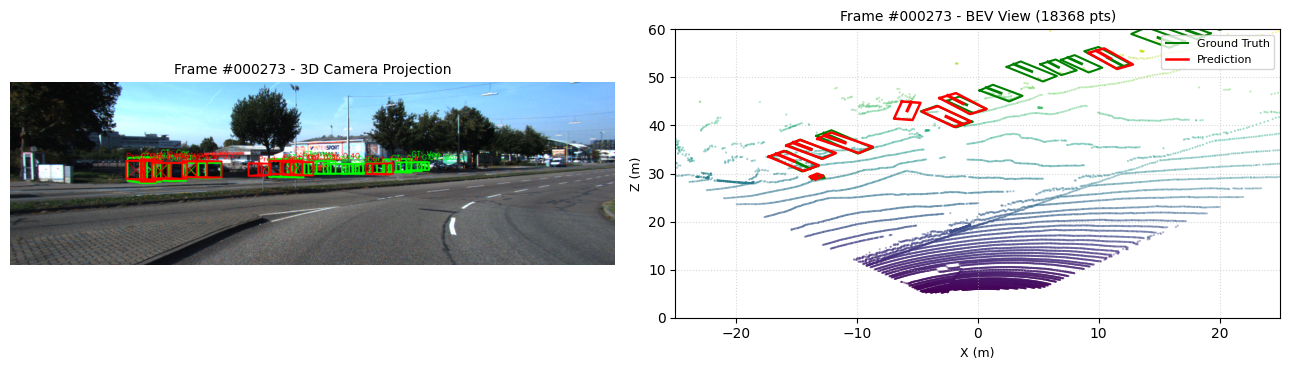

In [1]:
import sys

sys.path.insert(0, "/content/3D_Perception")
from scripts.sample_visualizer import SampleVisualizer

# Inizializzazione
visualizer = SampleVisualizer(
    data_path="/content/drive/MyDrive/3D_Perception/data/kitti_validation"
)

# Visualizza i 3 frame più significativi
visualizer.visualize_experiment(
    exp_dir="/content/drive/MyDrive/3D_Perception/experiments/beam_64rings",
    num_samples=1,
    conf_thresh=0.3,
)

### Visualize the 1/4-beam

 Saved compact grid visualization to Drive: /content/drive/MyDrive/3D_Perception/experiments/beam_16rings/visualizations/summary_grid_bev.png


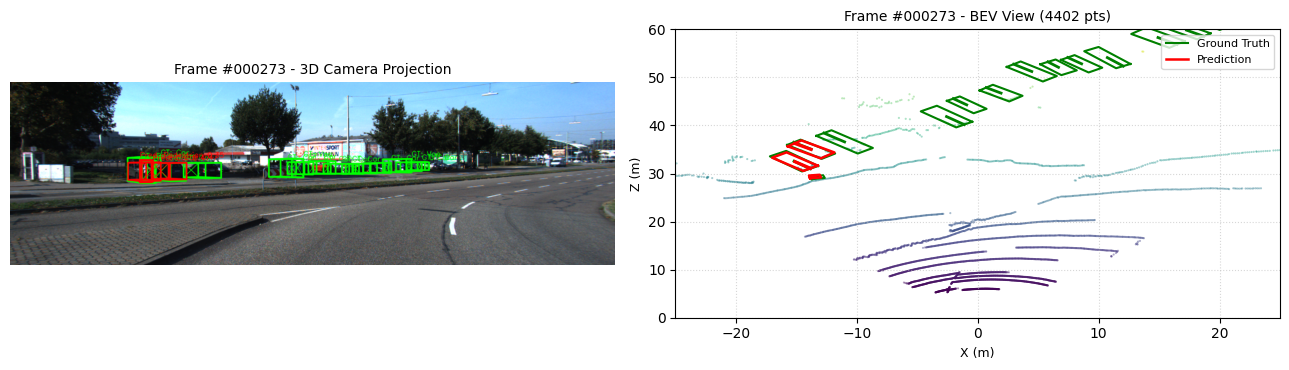

In [2]:
import sys

sys.path.insert(0, "/content/3D_Perception")
from scripts.sample_visualizer import SampleVisualizer

# Inizializzazione
visualizer = SampleVisualizer(
    data_path="/content/drive/MyDrive/3D_Perception/data/kitti_validation"
)

# Visualizza i 3 frame più significativi
visualizer.visualize_experiment(
    exp_dir="/content/drive/MyDrive/3D_Perception/experiments/beam_16rings",
    num_samples=1,
    conf_thresh=0.3,
)

### Experiment comparison

 Overall degradation plot saved to: /content/drive/MyDrive/3D_Perception/experiments/beam_degradation_car.png


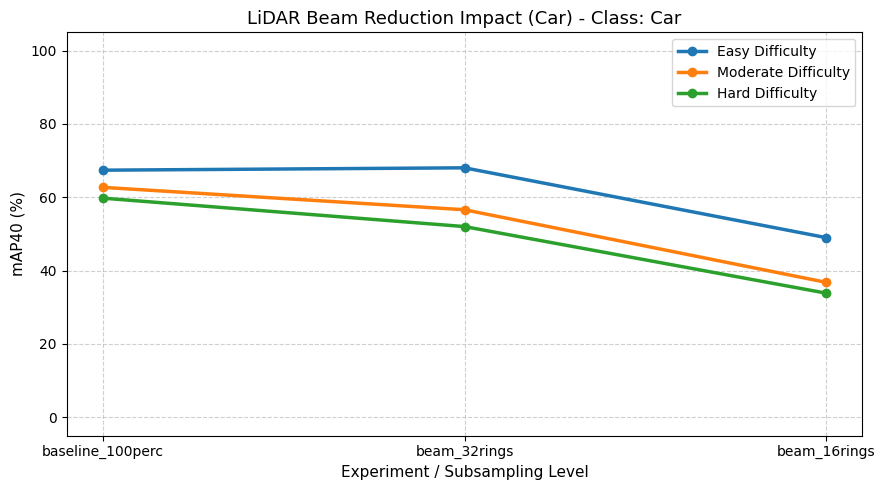

 Range degradation plot saved to: /content/drive/MyDrive/3D_Perception/experiments/beam_range_degradation.png


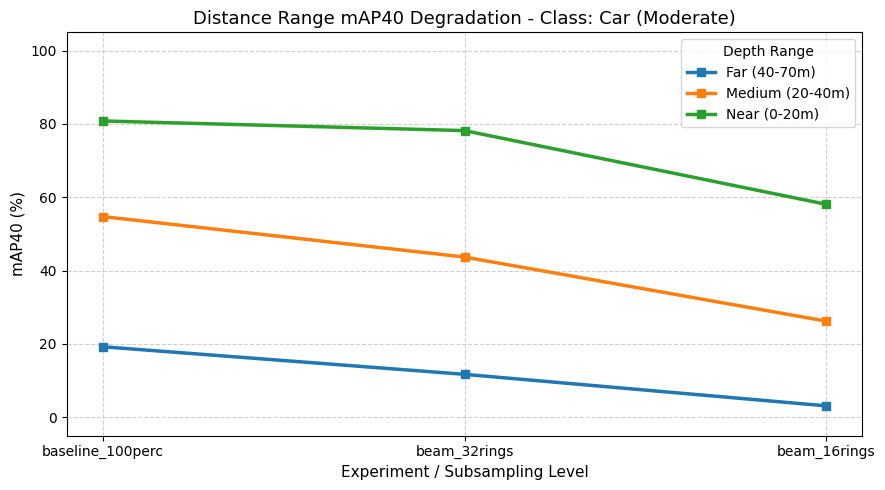

In [97]:
import sys

sys.path.insert(0, "/content/3D_Perception")
from scripts.experiment_comparer import ExperimentComparer

comparer = ExperimentComparer()

# Degradation curve for beam subsampling experiments
exp_sequence = ["baseline_100perc", "beam_32rings", "beam_16rings"]

comparer.plot_degradation_curves(
    exp_order=exp_sequence,
    target_class="Car",
    title="LiDAR Beam Reduction Impact (Car)",
    save_path="/content/drive/MyDrive/3D_Perception/experiments/beam_degradation_car.png",
)

# Degradation curve for range-based evaluation (Near, Medium, Far)
comparer.plot_range_degradation_curves(
    exp_order=exp_sequence,
    target_class="Car",
    difficulty="Moderate",
    save_path="/content/drive/MyDrive/3D_Perception/experiments/beam_range_degradation.png",
)